In [295]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [296]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../fourier/')
path.append('../signals/')

import frequency_estimate as fe
import integration as fint
import signals as sg

In [297]:
fs = 20
t1,s1 = sg.cosine(4,2,fs)
t2,s2 = sg.cosine(16,2,fs)

s1 += np.random.randn(s1.size)
s2 += np.random.randn(s2.size)

In [298]:
res1 = fe.symmetric_peak_periodogram(s1,fs,period=0.5,signal_band=(1,3), noise_band=(5, 50))
res2 = fe.symmetric_peak_periodogram(s2,fs,period=0.5,signal_band=(1,3), noise_band=(5, 50))

In [299]:
w = 1

pow1 = fint.integrate_psd(res1['power'], res1['frequencies'], res1['peak_freq'], w)
pow2 = fint.integrate_psd(res2['power'], res2['frequencies'], res2['peak_freq'], w)

In [300]:
pow1, pow2

(0.6346676600430884, 0.7612559165806764)

<Axes: xlabel='Frequency (Hz)', ylabel='Spectral power'>

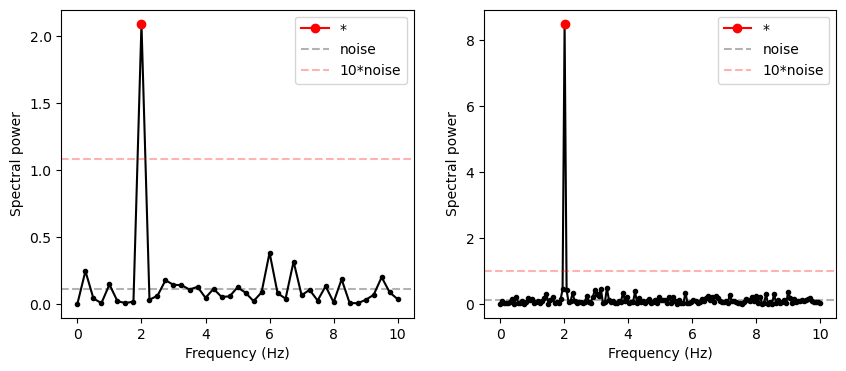

In [301]:
f, (ax,ax1) = plt.subplots(1,2,figsize=(10,4))
fe.plot_results(res1,ax=ax)
fe.plot_results(res2,ax=ax1)

In [320]:
n = 10000

pows1 = []
pows2 = []

for i in range(n):
    t1,s1 = sg.cosine(4,2,fs)
    t2,s2 = sg.cosine(16,2,fs)

    s1 += np.random.randn(s1.size)
    s2 += np.random.randn(s2.size)
    
    res1 = fe.symmetric_peak_periodogram(s1,fs,period=0.5,signal_band=(1,3), noise_band=(5, 50))
    res2 = fe.symmetric_peak_periodogram(s2,fs,period=0.5,signal_band=(1,3), noise_band=(5, 50))

    pows1.append(fint.integrate_psd(res1['power'], res1['frequencies'], res1['peak_freq'], w))
    pows2.append(fint.integrate_psd(res2['power'], res2['frequencies'], res2['peak_freq'], w))

Text(0.5, 0, 'Frequency (Hz)')

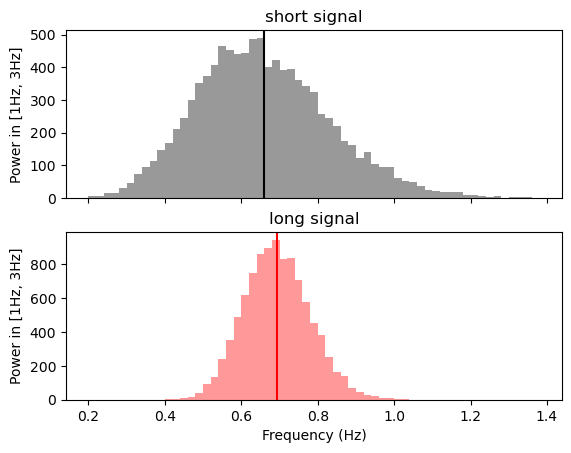

In [332]:
bins = np.arange(0.2, 1.4, 0.02)

f, (ax,ax1) = plt.subplots(2,1, sharex=True)

ax.hist(pows1, bins=bins, alpha=0.4, color='k')
ax.axvline(np.mean(pows1), color='k')
ax1.hist(pows2, bins=bins, alpha=0.4, color='r')
ax1.axvline(np.mean(pows2), color='r')

ax.set_title('short signal')
ax1.set_title('long signal')

ax.set_ylabel('Power in [1Hz, 3Hz]')
ax1.set_ylabel('Power in [1Hz, 3Hz]')
ax1.set_xlabel('Frequency (Hz)')